# Task 4: Customer Segmentation Using K-Means Clustering

## Objective

The objective of this task is to segment customers into different groups based on their purchasing behavior.

The Superstore dataset is used to calculate customer-level features such as total spending and purchase frequency. K-Means clustering is then applied to group customers with similar purchasing behavior.

The resulting clusters are visualized and analyzed to understand the characteristics of different customer segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("../Task1 - Data Cleaning/Cleaned_Superstore.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
customer_data = df.groupby("Customer ID").agg(
    Total_Spending=("Sales", "sum"),
    Purchase_Frequency=("Order ID", "nunique")
).reset_index()

In [5]:
customer_data.head()

,Customer ID,Total_Spending,Purchase_Frequency
0,AA-10315,5563.560,5
1,AA-10375,1056.390,9
2,AA-10480,1790.512,4
3,AA-10645,5086.935,6
4,AB-10015,886.156,3


In [6]:
customer_data.shape

(793, 3)

In [7]:
customer_data.describe()

,Total_Spending,Purchase_Frequency
count,793.000000,793.000000
mean,2851.874884,6.206810
std,2620.668723,2.525647
min,4.833000,1.000000
25%,1081.466000,4.000000
50%,2215.002000,6.000000
75%,3670.258000,8.000000
max,25043.050000,17.000000


In [11]:
X = customer_data[
    ["Total_Spending", "Purchase_Frequency"]
]

In [12]:
X.head()

,Total_Spending,Purchase_Frequency
0,5563.560,5
1,1056.390,9
2,1790.512,4
3,5086.935,6
4,886.156,3


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
X_scaled[:5]

array([[ 1.03538325, -0.47812351],
       [-0.6855571 ,  1.1066286 ],
       [-0.40525257, -0.87431153],
       [ 0.85339695, -0.08193548],
       [-0.75055632, -1.27049956]])

In [20]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [21]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )  
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

C:\Users\prasa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\prasa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\prasa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\prasa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

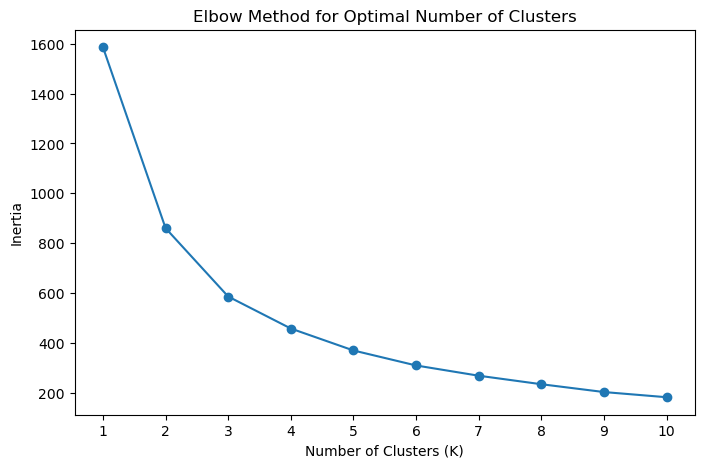

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(1, 11))
plt.show()

In [23]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\prasa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [24]:
customer_data.head()

,Customer ID,Total_Spending,Purchase_Frequency,Cluster
0,AA-10315,5563.560,5,1
1,AA-10375,1056.390,9,0
2,AA-10480,1790.512,4,1
3,AA-10645,5086.935,6,0
4,AB-10015,886.156,3,1


In [25]:
customer_data["Cluster"].value_counts().sort_index()

Cluster
0    292
1    422
2     79
Name: count, dtype: int64

In [26]:
cluster_summary = customer_data.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Average_Spending=("Total_Spending", "mean"),
    Average_Purchase_Frequency=("Purchase_Frequency", "mean")
).round(2)

cluster_summary

,Customers,Average_Spending,Average_Purchase_Frequency
Cluster,,,
0,292,3035.24,8.36
1,422,1603.31,4.35
2,79,8843.63,8.16


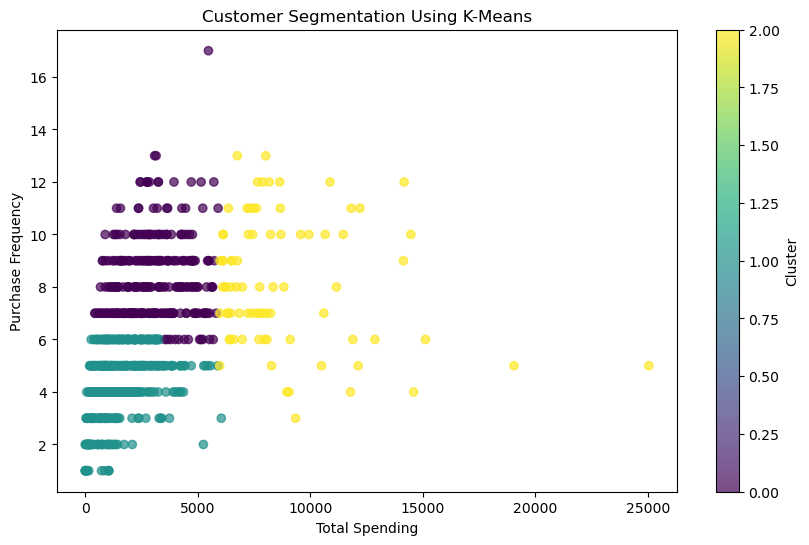

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(
    customer_data["Total_Spending"],
    customer_data["Purchase_Frequency"],
    c=customer_data["Cluster"],
    cmap="viridis",
    alpha=0.7
)
plt.title("Customer Segmentation Using K-Means")
plt.xlabel("Total Spending")
plt.ylabel("Purchase Frequency")
plt.colorbar(label="Cluster")
plt.show()

In [28]:
cluster_names = {
    0: "Regular High-Value Customers",
    1: "Occasional Low-Value Customers",
    2: "Premium Customers"
}
customer_data["Customer_Segment"] = customer_data["Cluster"].map(cluster_names)

In [29]:
customer_data[
    ["Customer ID", "Total_Spending", "Purchase_Frequency", "Customer_Segment"]
].head(10)

,Customer ID,Total_Spending,Purchase_Frequency,Customer_Segment
0,AA-10315,5563.560,5,Occasional Low-Value Customers
1,AA-10375,1056.390,9,Regular High-Value Customers
2,AA-10480,1790.512,4,Occasional Low-Value Customers
3,AA-10645,5086.935,6,Regular High-Value Customers
4,AB-10015,886.156,3,Occasional Low-Value Customers
5,AB-10060,7755.620,8,Premium Customers
6,AB-10105,14473.571,10,Premium Customers
7,AB-10150,966.710,5,Occasional Low-Value Customers
8,AB-10165,1113.838,8,Regular High-Value Customers
9,AB-10255,914.532,9,Regular High-Value Customers


In [30]:
final_summary = customer_data.groupby("Customer_Segment").agg(
    Customers=("Customer ID", "count"),
    Average_Spending=("Total_Spending", "mean"),
    Average_Purchase_Frequency=("Purchase_Frequency", "mean")
).round(2)
final_summary

,Customers,Average_Spending,Average_Purchase_Frequency
Customer_Segment,,,
Occasional Low-Value Customers,422,1603.31,4.35
Premium Customers,79,8843.63,8.16
Regular High-Value Customers,292,3035.24,8.36


## Customer Segmentation Findings

K-Means clustering was applied to segment customers based on total spending and purchase frequency. The Elbow Method suggested using three clusters.

### Cluster 0 — Regular High-Value Customers

This segment contains 292 customers with an average spending of 3035.24 and an average purchase frequency of 8.36. These customers make purchases relatively frequently and generate significant revenue.

### Cluster 1 — Occasional Low-Value Customers

This is the largest segment with 422 customers. Their average spending is 1603.31 and their average purchase frequency is 4.35. These customers purchase less frequently and have comparatively lower spending.

### Cluster 2 — Premium Customers

This segment contains 79 customers with an average spending of 8843.63 and an average purchase frequency of 8.16. They represent the highest-value customer group and should be prioritized for customer retention and loyalty strategies.

### Business Insight

The segmentation shows that customers have significantly different purchasing behaviors. The business can use these segments to design targeted marketing strategies. Premium customers can receive loyalty rewards, regular high-value customers can be encouraged to increase their spending, and occasional low-value customers can be targeted with personalized offers to increase purchase frequency.

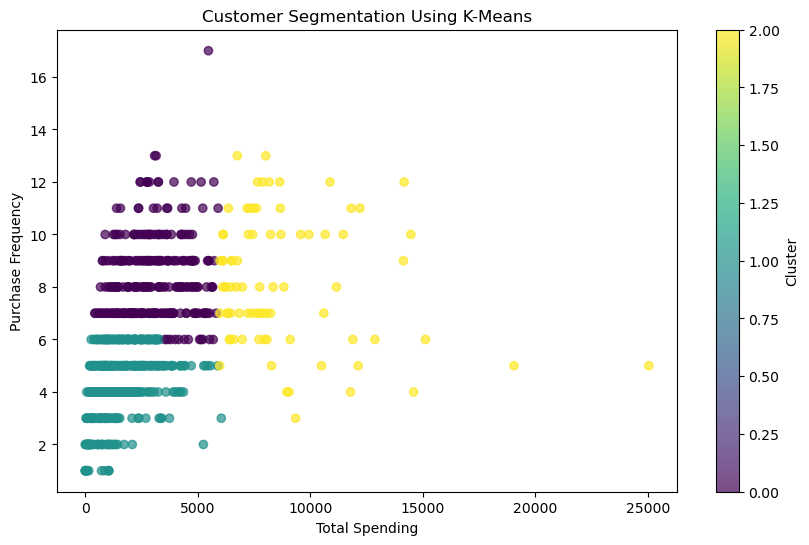

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(
    customer_data["Total_Spending"],
    customer_data["Purchase_Frequency"],
    c=customer_data["Cluster"],
    cmap="viridis",
    alpha=0.7
)
plt.title("Customer Segmentation Using K-Means")
plt.xlabel("Total Spending")
plt.ylabel("Purchase Frequency")
plt.colorbar(label="Cluster")
plt.savefig(
    "customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Conclusion

Customer segmentation was performed using the K-Means clustering algorithm on the Superstore dataset.

Customers were grouped based on two purchasing behavior features: total spending and purchase frequency. The Elbow Method was used to determine an appropriate number of clusters, and three clusters were selected.

The analysis identified three customer segments:

- Regular High-Value Customers
- Occasional Low-Value Customers
- Premium Customers

The segmentation provides useful business insights that can help organizations develop targeted marketing campaigns, customer retention strategies, and personalized offers.